# Visión por Computadora II - Trabajo Final

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Descripción del problema

- Tipo de problema: Clasificación
- Descripción: Detección de nódulos pulmonares en tomografías de tórax.
- Detalles: Desarrollar un modelo de aprendizaje profundo que identifique la presencia de nódulos pulmonares en imágenes de tomografía computarizada (CT) de tórax.​
- Dataset: [Chest CT-Scan images Dataset](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

## Imports

In [172]:
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


import torch

import numpy as np
import pandas as pd

import os
from zipfile import ZipFile
from typing import Tuple

import matplotlib.pyplot as plt
from collections import Counter

## Descarga del dataset

In [173]:
!curl -L -o "/content/dataset.zip" "https://www.kaggle.com/api/v1/datasets/download/mohamedhanyyy/chest-ctscan-images"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  118M  100  118M    0     0  25.6M      0  0:00:04  0:00:04 --:--:-- 28.5M


In [174]:
zip_file = "/content/dataset.zip"
dataset_unzip_folder = "/content/."
dataset_folder = "/content/Data"
DATASET_TRAIN = os.path.join(dataset_folder, "train")
DATASET_TEST = os.path.join(dataset_folder, "test")
DATASET_VALID = os.path.join(dataset_folder, "valid")

In [175]:
# Descomprimo si NO existe la carpeta /content/dataset_emociones
if not os.path.isdir(dataset_folder):
  with ZipFile(zip_file, 'r') as zip_object:
    zip_object.extractall(path=dataset_unzip_folder)

## EDA


Primero definimos una transformación básica en donde se aplica la transformación [ToTensor](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html).

Esta permite convertir una imagen en un *tensor*, lo cual es necesario para trabajar con algunos modelos de PyTorch. También permite escalar los valores de píxeles originales (rango $[0; 255]$) al rango $[0; 1]$.

Por el momento solo se aplica esta transformación, ya que deseamos hacer un análisis inicial del dataset, pero en pasos posteriores se agregarán otras transformaciones según sea conveniente.



In [176]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
])

Se crean los datasets de `train`, `test` y `validation` utilizando la clase [ImageFolder](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html).

En cada uno se aplica la transformación base definida en `basic_transform`.

In [177]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=basic_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=basic_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=basic_transform)

En cada dataset se tienen las siguientes cantidades de imágenes:

- `Train`: $613$
- `Test`: $315$
- `Validation`: $72$

In [178]:
print(f"Cantidad de imágenes en Train: {len(train_data)}")
print(f"Cantidad de imágenes en Test: {len(test_data)}")
print(f"Cantidad de imágenes en Validation: {len(validation_data)}")

Cantidad de imágenes en Train: 613
Cantidad de imágenes en Test: 315
Cantidad de imágenes en Validation: 72


A continuación se definen las siguientes funciones:

- `get_class_counts`: dado un dataset formado mediante un `ImageFolder`, devuelve una lista con el nombre de las clases y otra con la cantidad de ocurrencias de cada una.
- `plot_image_class_distribution`: realiza un gráfico de cantidad de ocurrencias de cada clase en un dataset formado por `ImageFolder`.

In [179]:
def get_class_counts(dataset: ImageFolder) -> Tuple[list, list]:
  """
  Dado un dataset de tipo ImageFolder, devuelve las clases y
  su cantidad de ocurrencias.

  Args:
    dataset (ImageFolder): Dataset sobre el cual se obtendrán las
      clases y sus cantidades de ocurrencias.
  Returns:
    Tuple[list, list]: Devuelve dos listas:
      class_names: nombre de clases del dataset.
      counts: cantidad de ocurrencia de cada clase en el dataset.
  """
  class_labels = dataset.targets
  class_counts = Counter(class_labels)
  class_names = train_data.classes
  counts = [class_counts[i] for i in range(len(class_names))]

  return class_names, counts

In [180]:
def plot_image_class_distribution(dataset: ImageFolder,
                                  datasetName: str = "train",
                                  figsize: tuple = (10, 6)):
  """
  Grafica la distribución de clases de un dataset de imágenes.

  Args:
    dataset (ImageFolder): dataset cuyas clases se graficarán.
    datasetName (str): nombre del dataset, que se utilizará para el título
      del gráfico.
    figsize (tuple): tamaño del gráfico. Por defecto es (10, 6).
  """
  class_names, counts = get_class_counts(dataset=dataset)

  plt.figure(figsize=figsize)
  plt.barh(class_names, counts)
  plt.xlabel("Cantidad de imágenes")
  plt.ylabel("Clases")
  plt.title(f"Distribución de imágenes por clases en dataset {datasetName}")
  plt.tight_layout()
  plt.show()

### Distribuciones de clases en cada dataset

El dataset de train tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $195$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $115$ |
| `normal` | $148$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $155$ |

Es decir, el dataset de `train` presenta un ligero desbalance de clases, siendo `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` la que mayor ocurrencias tiene, y `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` las que menos tiene.

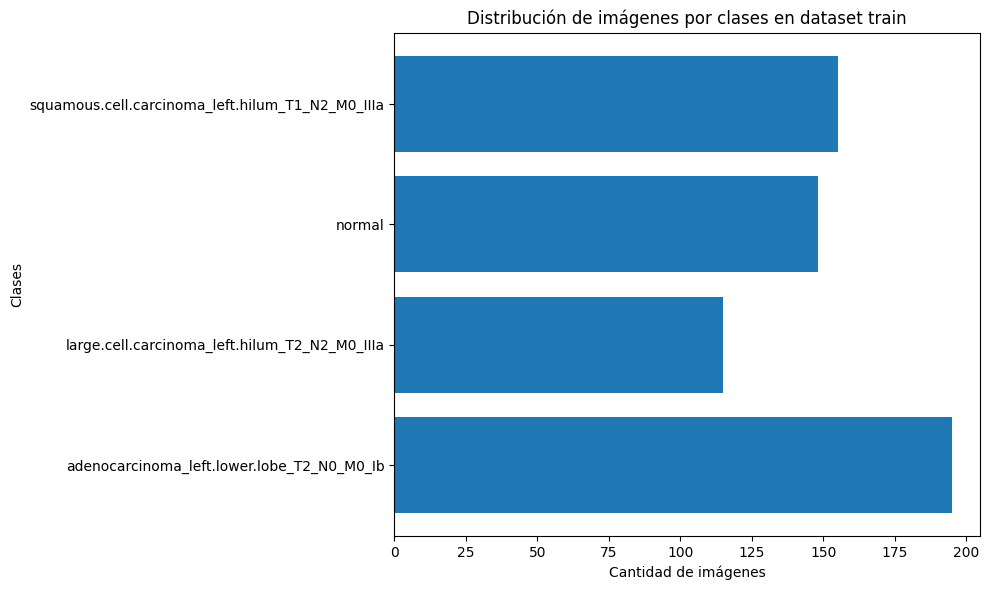

In [181]:
plot_image_class_distribution(dataset=train_data, datasetName="train")

El dataset de `test` tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $120$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $51$ |
| `normal` | $54$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $90$ |

Es decir, el dataset de `test` presenta ligero desbalance de clases, siendo `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` la que mayor ocurrencias tiene.

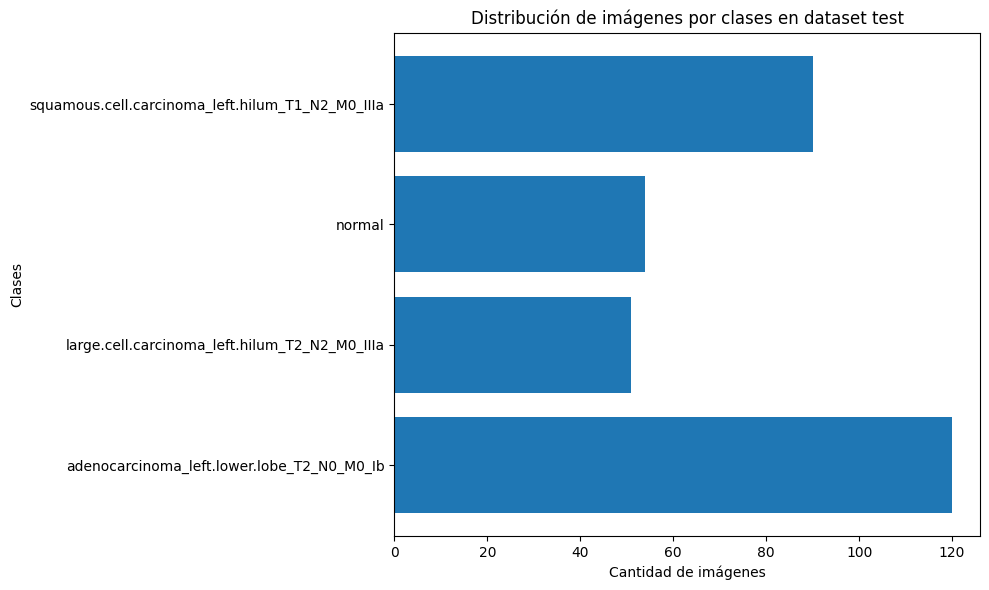

In [182]:
plot_image_class_distribution(dataset=test_data, datasetName="test")

El dataset de `validation` tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $23$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $21$ |
| `normal` | $13$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $15$ |

Es decir, este dataset está ligeramente desbalanceado.

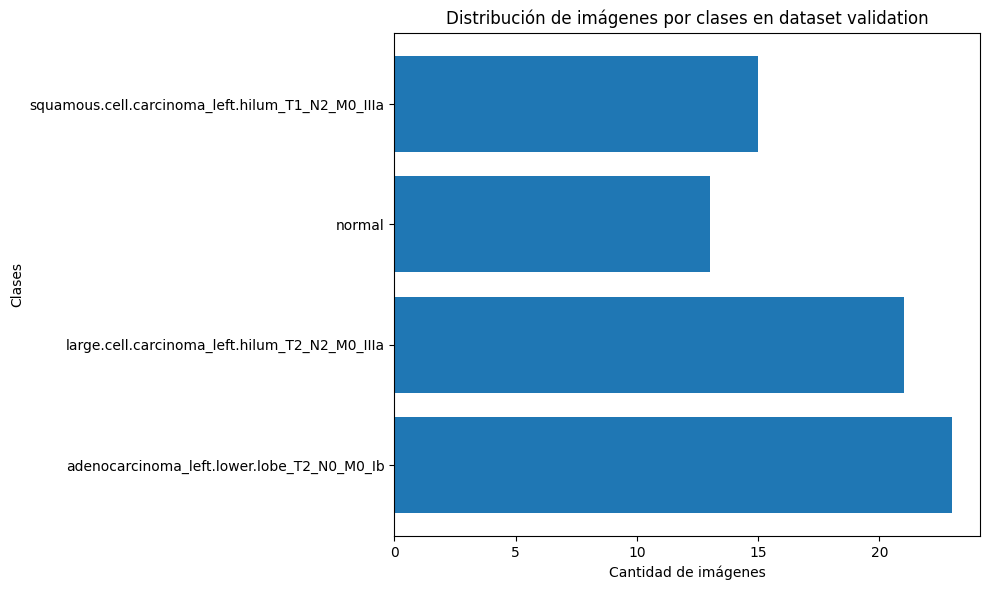

In [183]:
plot_image_class_distribution(dataset=validation_data, datasetName="validation")

### Análisis de dimensiones

En esta sección se analizan las dimensiones de las imágenes de los datasets de `train`, `test` y `validation`.

Comenzamos definiendo la función `get_shape_counts`, la cual devuelve las dimensiones de las imágenes de un dataset, como así también el *conteo* de sus ocurrencias.

Esto permitirá tener un primer acercamiento a las dimensiones de las imágenes de los datasets, que nos permitirá si todas tienen el mismo tamaño o no.

In [184]:
def get_shape_counts(dataset: ImageFolder) -> Counter:
  """
  Dado un dataset de tipo ImageFolder, devuelve las dimensiones de
  sus imágenes, junto la cantidad de ocurrencias.

  Args:
    dataset (ImageFolder): Dataset sobre el cual se obtendrán las
      clases y sus cantidades de ocurrencias.
  Returns:
    Counter: contador de ocurrencias de cada dimensión de imágen
    distinta en el dataset.
  """
  dataset_shapes = []

  for img in dataset:
    dataset_shapes.append(img[0].shape)

  dataset_counts = Counter(dataset_shapes)

  return dataset_counts

In [185]:
train_data_shape = get_shape_counts(dataset=train_data)
test_data_shape = get_shape_counts(dataset=test_data)
validation_data_shape = get_shape_counts(dataset=validation_data)

Para el dataset de `train` se observa que la mayoría de las imágenes tienen dimensiones distintas.

Solamente coinciden en la cantidad de canales ($3$ o `RGB`).

In [186]:
train_data_shape

Counter({torch.Size([3, 264, 409]): 1,
         torch.Size([3, 243, 397]): 1,
         torch.Size([3, 244, 392]): 1,
         torch.Size([3, 220, 377]): 1,
         torch.Size([3, 272, 373]): 1,
         torch.Size([3, 288, 449]): 1,
         torch.Size([3, 276, 389]): 1,
         torch.Size([3, 328, 384]): 1,
         torch.Size([3, 323, 417]): 1,
         torch.Size([3, 247, 341]): 1,
         torch.Size([3, 232, 386]): 1,
         torch.Size([3, 246, 410]): 1,
         torch.Size([3, 250, 390]): 1,
         torch.Size([3, 274, 414]): 1,
         torch.Size([3, 242, 423]): 1,
         torch.Size([3, 269, 419]): 1,
         torch.Size([3, 259, 429]): 1,
         torch.Size([3, 211, 373]): 1,
         torch.Size([3, 305, 413]): 1,
         torch.Size([3, 286, 413]): 1,
         torch.Size([3, 258, 387]): 1,
         torch.Size([3, 284, 377]): 1,
         torch.Size([3, 206, 432]): 1,
         torch.Size([3, 295, 391]): 1,
         torch.Size([3, 296, 396]): 1,
         torch.Size([3, 2

Para el dataset de `test` se observa lo mismo que en el dataset anterior: la mayoría de las imágenes tienen dimensiones distintas.

Solamente coinciden en la cantidad de canales ($3$ o `RGB`).

In [187]:
test_data_shape

Counter({torch.Size([3, 282, 381]): 1,
         torch.Size([3, 335, 486]): 1,
         torch.Size([3, 357, 483]): 1,
         torch.Size([3, 406, 456]): 1,
         torch.Size([3, 328, 464]): 1,
         torch.Size([3, 340, 485]): 1,
         torch.Size([3, 309, 379]): 1,
         torch.Size([3, 260, 439]): 1,
         torch.Size([3, 389, 460]): 1,
         torch.Size([3, 320, 444]): 1,
         torch.Size([3, 264, 484]): 1,
         torch.Size([3, 356, 454]): 1,
         torch.Size([3, 326, 465]): 1,
         torch.Size([3, 364, 406]): 1,
         torch.Size([3, 318, 453]): 1,
         torch.Size([3, 280, 409]): 1,
         torch.Size([3, 271, 400]): 1,
         torch.Size([3, 409, 468]): 1,
         torch.Size([3, 365, 422]): 1,
         torch.Size([3, 340, 443]): 1,
         torch.Size([3, 397, 475]): 1,
         torch.Size([3, 342, 456]): 1,
         torch.Size([3, 322, 456]): 1,
         torch.Size([3, 314, 429]): 1,
         torch.Size([3, 347, 454]): 1,
         torch.Size([3, 2

Para el dataset de `validation` sucede lo mismo que en los datasets anteriores.

In [188]:
validation_data_shape

Counter({torch.Size([3, 245, 315]): 1,
         torch.Size([3, 247, 395]): 1,
         torch.Size([3, 264, 439]): 1,
         torch.Size([3, 335, 424]): 1,
         torch.Size([3, 256, 406]): 1,
         torch.Size([3, 219, 381]): 1,
         torch.Size([3, 275, 394]): 1,
         torch.Size([3, 251, 377]): 1,
         torch.Size([3, 269, 338]): 1,
         torch.Size([3, 245, 431]): 1,
         torch.Size([3, 182, 374]): 1,
         torch.Size([3, 253, 358]): 1,
         torch.Size([3, 202, 361]): 1,
         torch.Size([3, 252, 359]): 1,
         torch.Size([3, 249, 408]): 1,
         torch.Size([3, 258, 356]): 1,
         torch.Size([3, 192, 345]): 1,
         torch.Size([3, 246, 421]): 1,
         torch.Size([3, 299, 379]): 1,
         torch.Size([3, 274, 409]): 1,
         torch.Size([3, 216, 353]): 1,
         torch.Size([3, 242, 408]): 1,
         torch.Size([3, 235, 388]): 1,
         torch.Size([3, 205, 386]): 1,
         torch.Size([3, 274, 353]): 1,
         torch.Size([3, 2

Para determinar cuales son los valores mínimos y máximos del ancho (width) y altura (height) de cada dataset, se crea primero la función `get_min_max_dimensions`.

Luego, se procesó cada dataset con dicha función, obteniendo los siguientes resultados:

| Dataset | Min. Height | Max. Height | Min. Width | Max. Width |
| --- | --- | --- | --- | --- |
| `Train` | $168$ | $1200$ | $110$ | $874$ |
| `Test` | $360$ | $940$ | $232$ | $700$ |
| `Validation` | $315$ | $940$ | $181$ | $627$ |

In [189]:
def get_min_max_dimensions(dataset: ImageFolder) -> Tuple[int, int, int, int]:
  """
  Devuelve las dimensiones máximas y mínimas de un dataset de imágenes:

  Args:
    dataset (ImageFolder): dataset cuyas imágenes serán analizadas.
  Returns:
    Tuple[int, int, int, int]: min_height, max_height, min_width, max_width.
  """
  widths = [d[0].shape[1] for d in dataset]
  heights = [d[0].shape[2] for d in dataset]

  return min(heights), max(heights), min(widths), max(widths)

In [190]:
min_height, max_height, min_width, max_width = get_min_max_dimensions(dataset=train_data)
print(f"Dimensiones del dataset de TRAIN:\n\tmin_height: {min_height}\n\tmax_height: {max_height}\n\tmin_width: {min_width}\n\tmax_width: {max_width}")

Dimensiones del dataset de TRAIN:
	min_height: 168
	max_height: 1200
	min_width: 110
	max_width: 874


In [191]:
min_height, max_height, min_width, max_width = get_min_max_dimensions(dataset=test_data)
print(f"Dimensiones del dataset de TEST:\n\tmin_height: {min_height}\n\tmax_height: {max_height}\n\tmin_width: {min_width}\n\tmax_width: {max_width}")

Dimensiones del dataset de TEST:
	min_height: 360
	max_height: 940
	min_width: 232
	max_width: 700


In [192]:
min_height, max_height, min_width, max_width = get_min_max_dimensions(dataset=validation_data)
print(f"Dimensiones del dataset de VALIDATION:\n\tmin_height: {min_height}\n\tmax_height: {max_height}\n\tmin_width: {min_width}\n\tmax_width: {max_width}")

Dimensiones del dataset de VALIDATION:
	min_height: 315
	max_height: 940
	min_width: 181
	max_width: 627


***Conclusión***

Los tres datasets presentan imágenes de distintas dimensiones, lo cual puede llegar a ser perjudicial en el procesamiento de las mismas, ya que al trabajar con [Dataloader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) las imágenes deben tener las mismas ***dimensiones***.

Por este motivo será necesario aplicar una ***transformación de dimensiones*** en los datasets mediante la función [Resize](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Resize.html).

### Visualización de imágenes

Con el fin de analizar las imágenes de los distintos datasets, comenzamos primero redefiniendo las transformaciones a aplicar.

En particular, se agrega la transformación [Resize](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Resize.html), la cual permite redimensionar las imágenes en un *ancho* y *alto* determinados.

En este caso, a fin de hacer una primer aproximación a las imágenes, se opta por redimensionar a $128 x 128$.

Posteriormente se analizará si esta dimensión es la ideal o no.

In [283]:
basic_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [284]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=basic_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=basic_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=basic_transform)

A continuación se crean los [DataLoader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) de cada dataset, que serán útiles para la carga de imágenes y su posterior procesamiento.

In [285]:
BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE)

In [286]:
def show_images_from_loader(dataloader: DataLoader, figsize: tuple = (10, 10),
                            rows: int = 5, nrow: int = 5):
  """
  Muestra N imágenes de un dataloader.

  Args:
    dataloader (DataLoader): dataloader con las imágenes a mostrar.
    figsize (tuple): Tupla que indica el tamaño de la imagen resultante.
    rows (int): Cantidad de filas a mostrar en la imagen resultante.
    nrow (int): Cantidad de imágenes por filas.
  Raise:
    ValueError: si el product de nrow y row es mayor al batch_size del dataloader.
  """
  if (rows * nrow) > dataloader.batch_size:
    raise ValueError(f"El producto de rows y nrows ({rows} * {nrow}) debe ser menor o igual a batch_size del dataloader ({dataloader.batch_size}).")

  dataiter = iter(dataloader)
  images, labels = next(dataiter)

  plt.figure(figsize=figsize)
  plt.imshow(np.transpose(torchvision.utils.make_grid(
      images[:rows * nrow], nrow=nrow).numpy(), (1, 2, 0)))
  plt.axis('off')
  plt.show()

Se muestran a continuación las primeras $25$ imágenes del dataset de `train`:

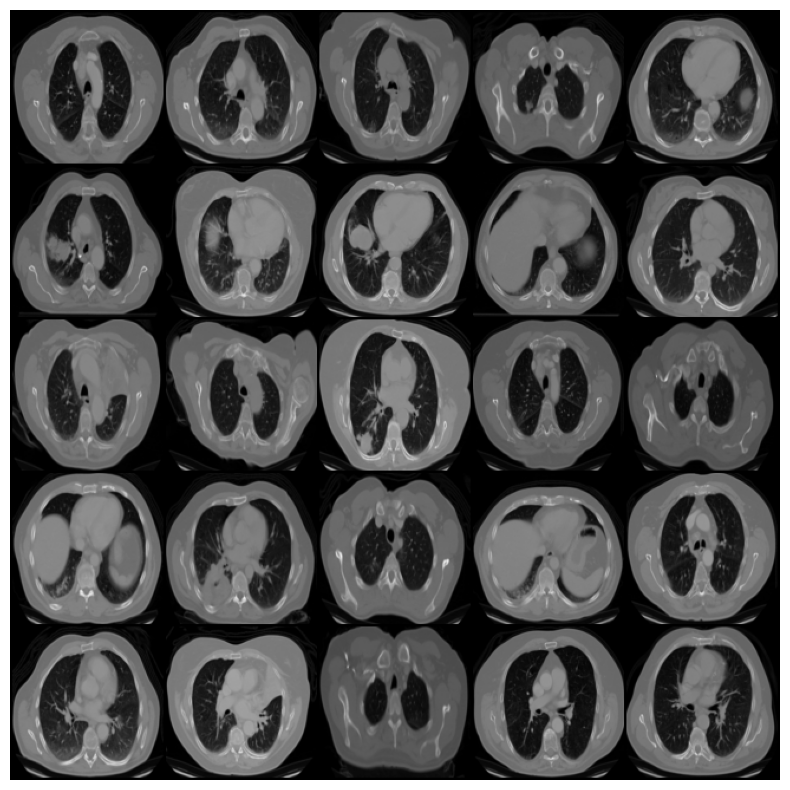

In [287]:
show_images_from_loader(dataloader=train_loader)

Se muestran a continuación las primeras $25$ imágenes del dataset de `test`:

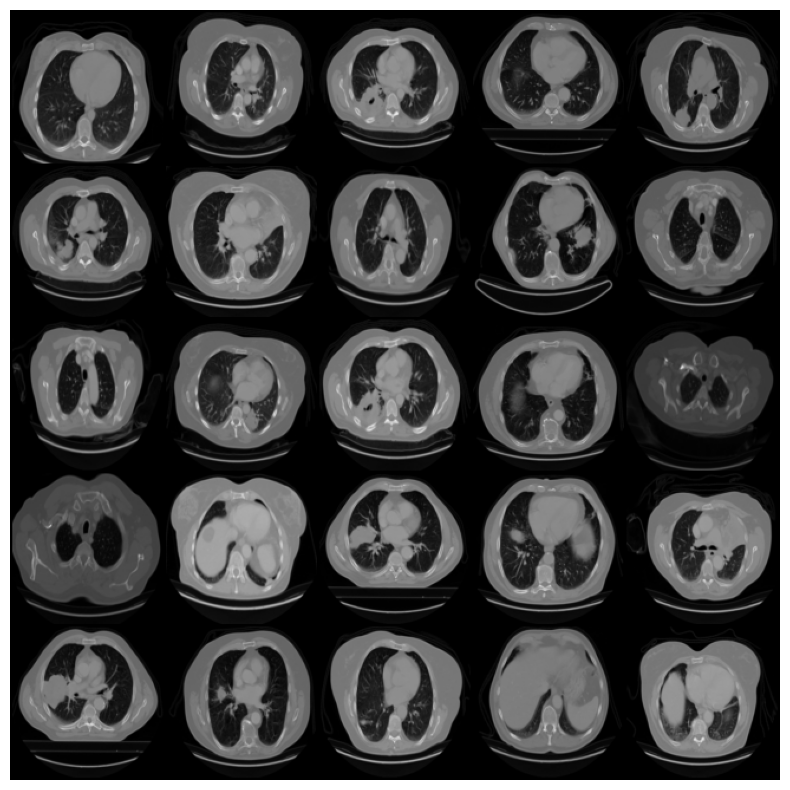

In [288]:
show_images_from_loader(dataloader=test_loader)

Se muestran a continuación las primeras $25$ imágenes del dataset de `validation`:

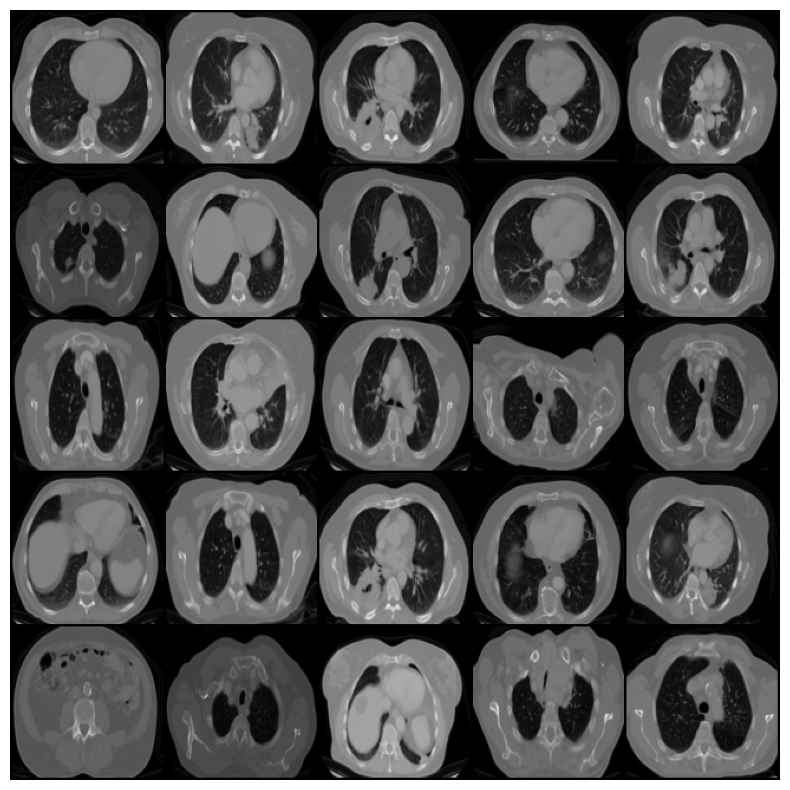

In [289]:
show_images_from_loader(dataloader=validation_loader)

***Conclusiones***

Si bien no es una conclusión final, un preprocesamiento/transformación que vale la pena estudiar es [Grayscale](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Grayscale.html), la cual convierte las imágenes en escala de grises.

Esto también beneficia que las imágenes tienen una vez procesadas `un solo canal`, lo cual facilitará los tiempos de procesamiento al entrenar los futuros modelos con los que se trabajará.

### Imágenes promedio por clases

Comenzamos recreando los dataloaders, pero en este caso con un `BATCH_SIZE` igual a $1$, a fin de procesar imagen a imagen.

In [290]:
BATCH_SIZE = 1

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE)

Luego se crea la función `get_mean_image`, la cual, dado un dataloader y una lista de clases de imágenes dentro del mismo, devuelve la ***imagen promedio***.

Esta será util para analizar no solo como luce la imagen promedio de cada clase, sino las diferencias entre el promedio de la clase `Normal` con el resto de clases.

A partir de este análisis podremos determinar si es util aplicar ciertos preprocesamientos o no.

In [291]:
def get_mean_image(dataloader: DataLoader, channels: int = 3, height: int = 128,
                   width: int = 128,
                   labels_to_show: list = [0, 1, 2, 3]) -> np.ndarray:
  """
  Devuelve como se ve la "imagen promedio" de un dataloader.

  Args:
    dataloader (DataLoader): dataloader cuyas imágenes serán procesadas.
    channels (int): cantidad de canales que tienen las imágenes. Por defecto
      es 3.
    height (int): altura de las imágenes. Por defecto es 128.
    width (int): ancho de las imágenes. Por defecto es 128.
    labels_to_show (list): índice de los labels/clases del dataset a procesar.
  Returns:
    (np.ndarray): Imagen promedio del dataset, de la clase indicada.
  """
  mean_image_sum = torch.zeros(channels, height, width)
  num_images = 0

  for images, labels in dataloader:
      if labels in labels_to_show:
        mean_image_sum += torch.sum(images, dim=0)
        num_images += images.shape[0]

  mean_image = mean_image_sum / num_images

  if channels == 1:
    mean_image = mean_image.squeeze().numpy()

  if channels == 3:
    mean_image = mean_image.permute(1, 2, 0).numpy()
  return mean_image

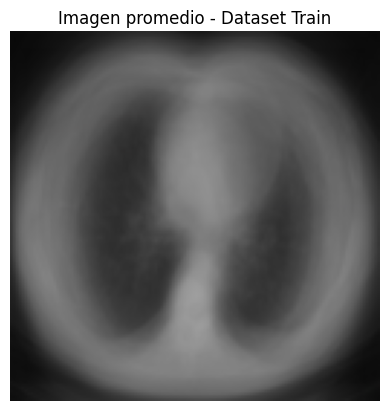

In [292]:
train_mean_all_classes = get_mean_image(dataloader=train_loader)

plt.imshow(train_mean_all_classes, cmap='bwr')
plt.title("Imagen promedio - Dataset Train")
plt.axis('off')
plt.show()

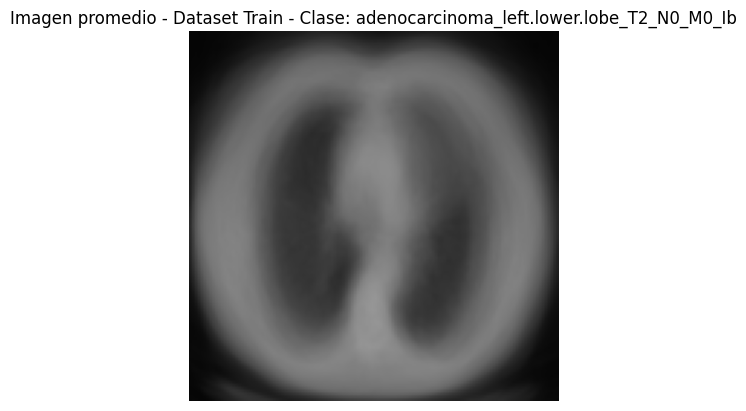

In [293]:
train_mean_0 = get_mean_image(dataloader=train_loader, labels_to_show=[0])

plt.imshow(train_mean_0, cmap='bwr')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[0]}")
plt.axis('off')
plt.show()

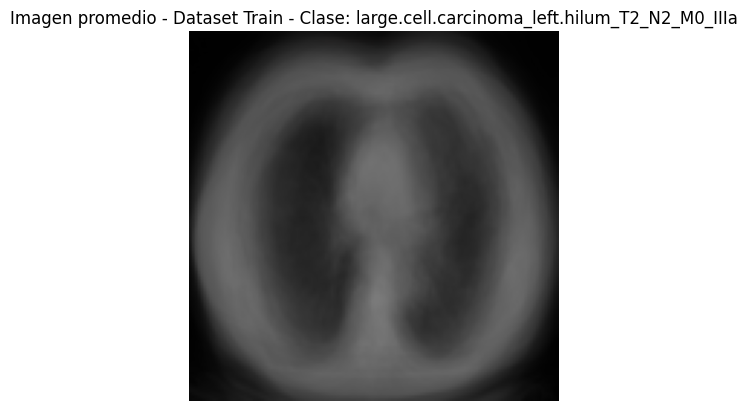

In [294]:
train_mean_1 = get_mean_image(dataloader=train_loader, labels_to_show=[1])

plt.imshow(train_mean_1, cmap='bwr')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[1]}")
plt.axis('off')
plt.show()

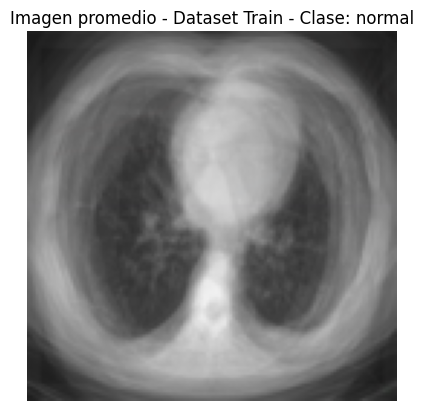

In [295]:
train_mean_2 = get_mean_image(dataloader=train_loader, labels_to_show=[2])

plt.imshow(train_mean_2, cmap='bwr')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[2]}")
plt.axis('off')
plt.show()

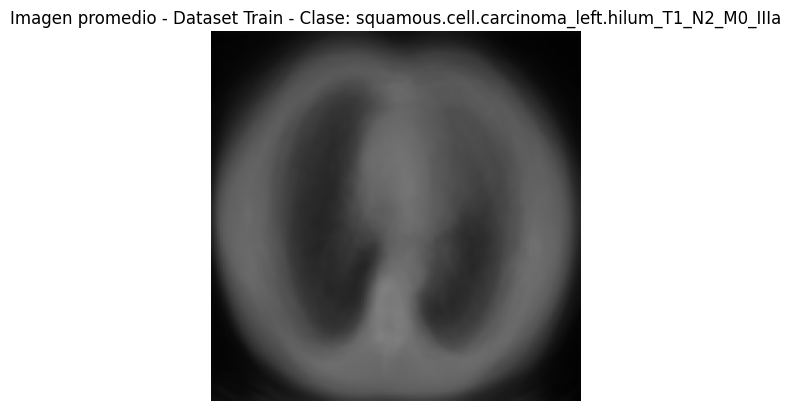

In [296]:
train_mean_3 = get_mean_image(dataloader=train_loader, labels_to_show=[3])

plt.imshow(train_mean_3, cmap='bwr')
plt.title(f"Imagen promedio - Dataset Train - Clase: {train_data.classes[3]}")
plt.axis('off')
plt.show()

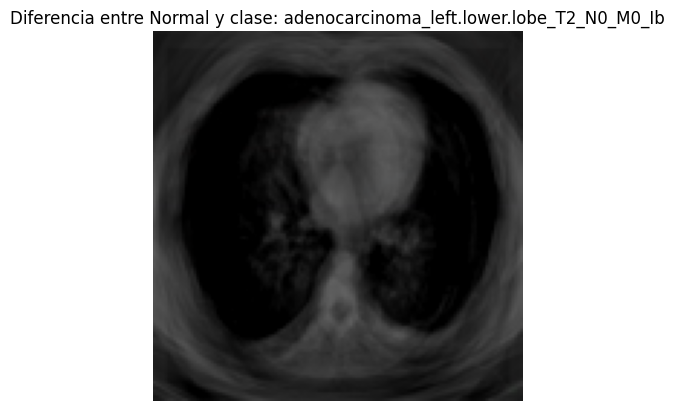

In [304]:
contrast_mean_2_0 = train_mean_2 - train_mean_0

plt.imshow(contrast_mean_2_0, cmap='bwr')
plt.title(f"Diferencia entre Normal y clase: {train_data.classes[0]}")
plt.axis('off')
plt.show()

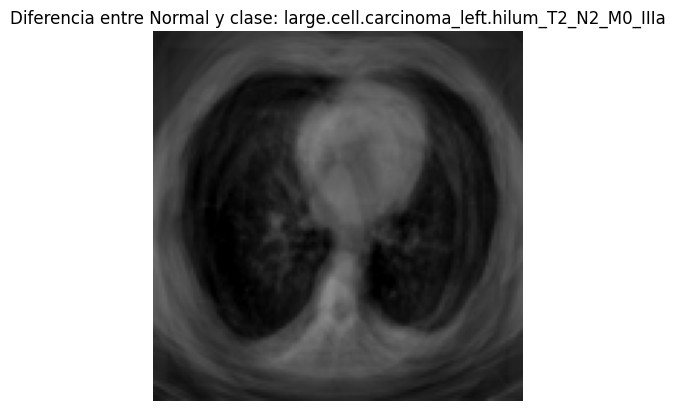

In [302]:
contrast_mean_2_1 = train_mean_2 - train_mean_1

plt.imshow(contrast_mean_2_1, cmap='bwr')
plt.title(f"Diferencia entre Normal y clase: {train_data.classes[1]}")
plt.axis('off')
plt.show()

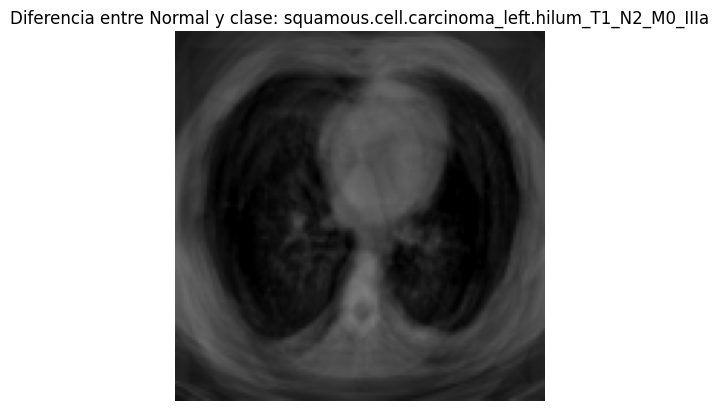

In [303]:
contrast_mean_2_3 = train_mean_2 - train_mean_3

plt.imshow(contrast_mean_2_3, cmap='bwr')
plt.title(f"Diferencia entre Normal y clase: {train_data.classes[3]}")
plt.axis('off')
plt.show()

### <Otro análisis>